# Eksperyment 10: Wpływ rozmiaru słownika na jakość generowanych opisów

## Wstęp teoretyczny
Analizujemy, jak ograniczenia w słowniku (kontrolowane parametrem `min_word_freq` podczas preprocessingu) wpływają na jakość generacji podpisów, w tym na częstość tokenów `<unk>` i spadek BLEU.
- Token `<unk>` ("unknown") zastępuje słowa, które nie są w słowniku modelu.
- Wyższe wartości `min_word_freq` zmniejszają słownik (oszczędność pamięci), ale mogą zwiększyć liczbę `<unk>` w generacji.
- Celem jest znalezienie optymalnego kompromisu między rozmiarem słownika a jakością opisów.

## Cel i metodyka
W tym eksperymencie sprawdzamy, jak próg `min_word_freq` wpływa na rozmiar słownika, pokrycie korpusu i jakość generowanych opisów.
- Najpierw analizujemy bieżący model z `min_word_freq=5` i mierzymy częstość występowania tokenu `<unk>`.
- Następnie symulujemy słowniki dla kilku progów częstotliwości, aby zobaczyć kompromis między rozmiarem słownika a pokryciem danych.
- Na końcu porównujemy BLEU-4 z udziałem `<unk>` oraz pokazujemy najważniejsze zależności na wykresach.

In [6]:
import json
import torch
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from collections import Counter

sys.path.insert(0, os.path.abspath('..'))
from caption import caption_image_beam_search
from models import Encoder, DecoderWithAttention

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Current model uses min_word_freq=5
CHECKPOINT_PATH = '../BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq_state_dict.pth.tar'
WORDMAP_PATH = '../dataset/WORDMAP_coco_5_cap_per_img_5_min_word_freq.json'
DATASET_PATH = '../dataset/caption_datasets/dataset_coco.json'


def load_model_from_checkpoint(checkpoint_path, vocab_size):
    """Load either a portable state-dict checkpoint or a legacy full checkpoint."""
    checkpoint = None
    try:
        checkpoint = torch.load(checkpoint_path, map_location=str(device), weights_only=True)
    except Exception:
        try:
            checkpoint = torch.load(checkpoint_path, map_location=str(device), weights_only=False)
        except Exception:
            checkpoint = torch.load(checkpoint_path, map_location=str(device))

    if isinstance(checkpoint, dict) and 'encoder_state_dict' in checkpoint and 'decoder_state_dict' in checkpoint:
        encoder = Encoder()
        encoder.load_state_dict(checkpoint['encoder_state_dict'], strict=False)
        encoder = encoder.to(device).eval()

        decoder = DecoderWithAttention(attention_dim=512,
                                       embed_dim=512,
                                       decoder_dim=512,
                                       vocab_size=vocab_size,
                                       dropout=0.5)
        decoder.load_state_dict(checkpoint['decoder_state_dict'], strict=False)
        decoder = decoder.to(device).eval()
        return encoder, decoder, checkpoint

    decoder = checkpoint['decoder'].to(device).eval()
    encoder = checkpoint['encoder'].to(device).eval()
    return encoder, decoder, checkpoint


# Load word map first so we know vocabulary size for portable checkpoints.
with open(WORDMAP_PATH, 'r') as f:
    word_map = json.load(f)
rev_word_map = {v: k for k, v in word_map.items()}

# Load current model and word map
encoder, decoder, checkpoint = load_model_from_checkpoint(CHECKPOINT_PATH, len(word_map))

with open(DATASET_PATH, 'r') as f:
    dataset = json.load(f)

# Build references
references = {}
for img in dataset['images']:
    references[img['filename']] = [[token for token in sent['tokens']] for sent in img['sentences']]

print(f"Current vocabulary size (min_word_freq=5): {len(word_map)}")
print("Data loaded")

/run/media/krzysiek/E482074E82072520/magister/sem3/adom/Show-and-Tell/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/run/media/krzysiek/E482074E82072520/magister/sem3/adom/Show-and-Tell/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Current vocabulary size (min_word_freq=5): 9490
Data loaded


## Przygotowanie danych i modelu
Na tym etapie ładujemy checkpoint, słownik i zbiór referencyjnych podpisów.
To daje nam punkt odniesienia do dalszej analizy wpływu `min_word_freq` na generację.
- model i encoder są ustawiane w trybie `eval()`
- budujemy mapę odwrotną `id -> słowo`
- przygotowujemy referencje COCO dla obrazów walidacyjnych i testowych

In [2]:
# Generate captions with current model and analyze <unk> token usage
num_test = 50
test_files = list(references.keys())[:num_test]

unk_token_id = word_map.get('<unk>', None)
results = []

print(f"\nGenerating captions for {num_test} images to analyze <unk> token usage...")

with torch.no_grad():
    for idx, filename in enumerate(test_files):
        if (idx + 1) % 10 == 0:
            print(f"  Processed {idx + 1}/{num_test}")

        fpath = os.path.join('../dataset/val2014', filename)
        if not os.path.exists(fpath):
            continue

        try:
            seq, _ = caption_image_beam_search(encoder, decoder, fpath, word_map, 5)
            hyp = [rev_word_map[i] for i in seq if i not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}]

            # Count <unk> tokens in the sequence
            unk_count = sum(1 for token_id in seq if token_id == unk_token_id)
            seq_length = len([i for i in seq if i not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}])

            ref_captions = references[filename]
            smoother = SmoothingFunction().method1
            bleu = sentence_bleu(ref_captions, hyp, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoother)

            results.append({
                'filename': filename,
                'caption': ' '.join(hyp),
                'bleu_4': bleu,
                'unk_count': unk_count,
                'caption_length': seq_length,
                'unk_ratio': unk_count / seq_length if seq_length > 0 else 0,
            })
        except Exception:
            continue

df_current = pd.DataFrame(results)
print(f"Completed analysis on {len(df_current)} images")


Generating captions for 50 images to analyze <unk> token usage...
  Processed 10/50
  Processed 20/50
  Processed 30/50
  Processed 40/50
  Processed 50/50
Completed analysis on 50 images


## Ocena bieżącego modelu
Najpierw generujemy podpisy dla próbki obrazów z aktualnym słownikiem.
Sprawdzamy, czy model faktycznie używa tokenów `<unk>` i jaka jest średnia jakość generacji.
Wynik tej sekcji stanowi bazę do porównania z symulacją różnych progów `min_word_freq`.

In [16]:
def simulate_reduced_vocabulary(min_freq):
    """Simulate what vocabulary would look like with different min_word_freq."""
    word_freq = Counter()

    # Count word frequencies exactly like create_input_files.py does:
    # it updates the counter for every caption in the dataset, regardless of split,
    # and later keeps only words with frequency > min_word_freq.
    for img in dataset['images']:
        for sent in img['sentences']:
            word_freq.update(sent['tokens'])

    # Create vocabulary with the same threshold rule as the preprocessing code.
    # Words with frequency <= min_freq are mapped to <unk>.
    vocab = {w: i + 1 for i, w in enumerate(sorted(w for w, f in word_freq.items() if f > min_freq))}
    vocab['<unk>'] = len(vocab) + 1
    vocab['<start>'] = len(vocab) + 1
    vocab['<end>'] = len(vocab) + 1
    vocab['<pad>'] = 0

    return vocab, word_freq

# Simulate vocabularies with different min_word_freq values
vocab_analysis = []
test_freqs = [1, 5, 10, 50, 100]

print("Simulating vocabulary sizes for different min_word_freq values:")
print(f"{'min_word_freq':<15} {'Vocab Size':<15} {'% Coverage':<15}")
print("-" * 45)

for min_freq in test_freqs:
    vocab, word_freq = simulate_reduced_vocabulary(min_freq)

    # Calculate coverage
    total_words_in_corpus = sum(word_freq.values())
    covered_words = sum(f for w, f in word_freq.items() if f > min_freq)
    coverage = (covered_words / total_words_in_corpus) * 100

    vocab_analysis.append({
        'min_word_freq': min_freq,
        'vocab_size': len(vocab) - 4,  # Exclude special tokens
        'total_vocab_with_special': len(vocab),
        'coverage_pct': coverage,
    })

    print(f"{min_freq:<15} {len(vocab):<15} {coverage:.1f}%")

df_vocab = pd.DataFrame(vocab_analysis)

Simulating vocabulary sizes for different min_word_freq values:
min_word_freq   Vocab Size      % Coverage     
---------------------------------------------
1               16590           99.8%
5               9490            99.5%
10              7253            99.2%
50              3463            97.9%
100             2424            96.7%


## Symulacja słownika
W tej sekcji sprawdzamy, jak zmiana progu częstotliwości wpływałaby na wielkość słownika i pokrycie korpusu.
To pozwala oszacować koszt ograniczania słownika jeszcze zanim przeprowadzimy pełne trenowanie modelu.
Porównujemy kilka wartości `min_word_freq`, żeby zobaczyć, gdzie zaczyna się zauważalny spadek pokrycia.


=== Current Model Performance (min_word_freq=5) ===
Mean BLEU-4: 0.3402
Mean caption length: 8.7 tokens
Mean <unk> token ratio: 0.0000 (0.00%)
Images with at least one <unk>: 0 / 50
Trend line skipped: insufficient variation in <unk> ratio values.


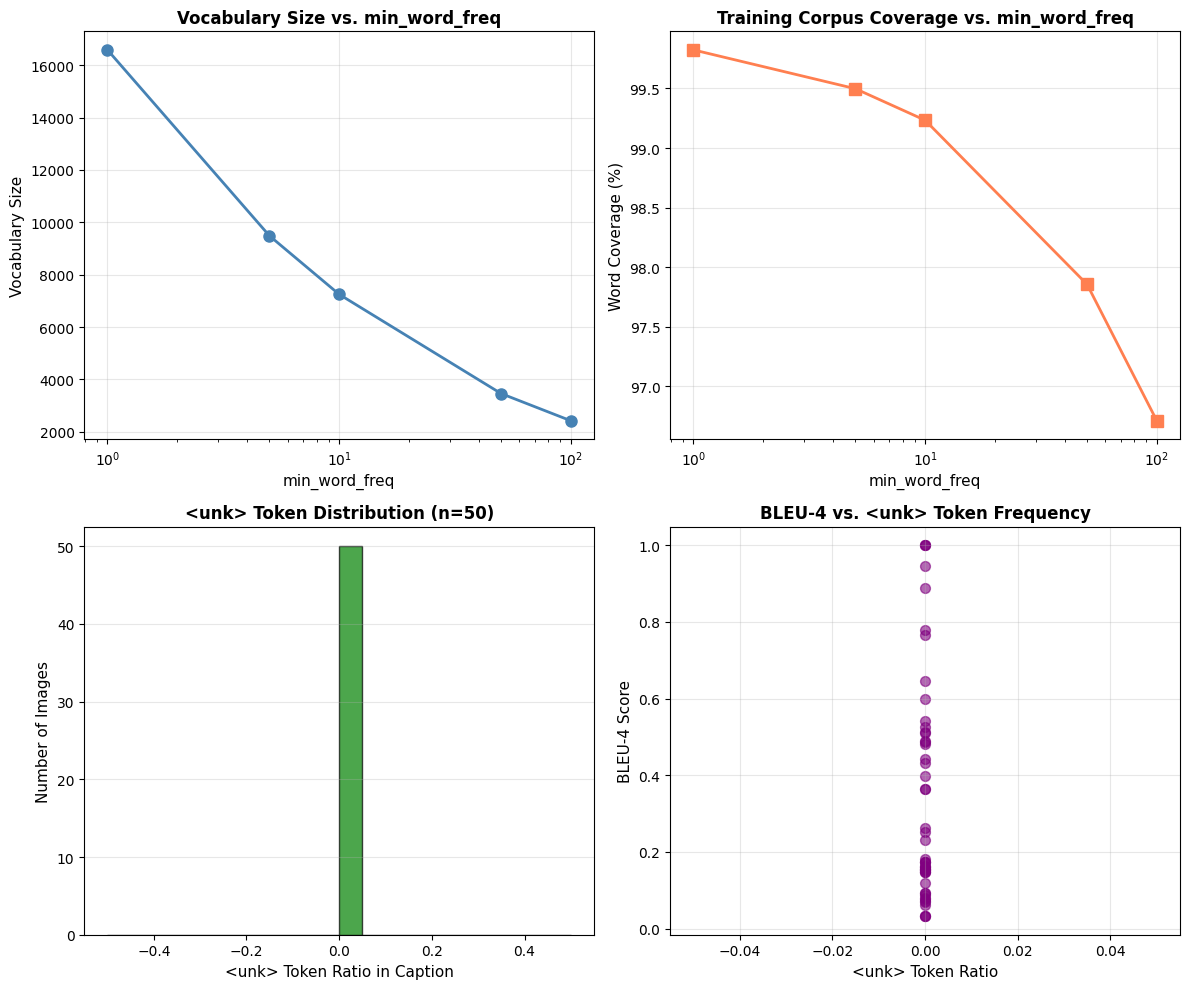


=== Key Insights ===
1. Vocabulary size stays above 90% coverage up to min_word_freq=1.
2. Current model does not emit <unk> tokens in the sampled captions (<unk> ratio: 0.0000).
3. Because all sampled captions have <unk> ratio = 0, the BLEU-4 vs <unk> scatter is degenerate and does not show a meaningful trend.
4. The trade-off that is clearly visible is vocabulary size vs corpus coverage: larger min_word_freq sharply reduces vocabulary size while slightly lowering coverage.


In [17]:
# Analysis and visualization
print("\n=== Current Model Performance (min_word_freq=5) ===")
print(f"Mean BLEU-4: {df_current['bleu_4'].mean():.4f}")
print(f"Mean caption length: {df_current['caption_length'].mean():.1f} tokens")
print(f"Mean <unk> token ratio: {df_current['unk_ratio'].mean():.4f} ({df_current['unk_ratio'].mean()*100:.2f}%)")
print(f"Images with at least one <unk>: {(df_current['unk_count'] > 0).sum()} / {len(df_current)}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Vocabulary size vs coverage
axes[0, 0].plot(df_vocab['min_word_freq'], df_vocab['vocab_size'], 'o-', linewidth=2, markersize=8, color='steelblue')
axes[0, 0].set_xlabel('min_word_freq', fontsize=11)
axes[0, 0].set_ylabel('Vocabulary Size', fontsize=11)
axes[0, 0].set_title('Vocabulary Size vs. min_word_freq', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xscale('log')

# Coverage
axes[0, 1].plot(df_vocab['min_word_freq'], df_vocab['coverage_pct'], 's-', linewidth=2, markersize=8, color='coral')
axes[0, 1].set_xlabel('min_word_freq', fontsize=11)
axes[0, 1].set_ylabel('Word Coverage (%)', fontsize=11)
axes[0, 1].set_title('Training Corpus Coverage vs. min_word_freq', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xscale('log')

# <unk> token distribution
axes[1, 0].hist(df_current['unk_ratio'], bins=20, color='green', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('<unk> Token Ratio in Caption', fontsize=11)
axes[1, 0].set_ylabel('Number of Images', fontsize=11)
axes[1, 0].set_title(f'<unk> Token Distribution (n={len(df_current)})', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# BLEU vs <unk> ratio
axes[1, 1].scatter(df_current['unk_ratio'], df_current['bleu_4'], alpha=0.6, s=50, color='purple')
axes[1, 1].set_xlabel('<unk> Token Ratio', fontsize=11)
axes[1, 1].set_ylabel('BLEU-4 Score', fontsize=11)
axes[1, 1].set_title('BLEU-4 vs. <unk> Token Frequency', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

# Add trend line only when the fit is well-defined
x_vals = np.asarray(df_current['unk_ratio'], dtype=float)
y_vals = np.asarray(df_current['bleu_4'], dtype=float)
valid_mask = np.isfinite(x_vals) & np.isfinite(y_vals)
x_valid = x_vals[valid_mask]
y_valid = y_vals[valid_mask]

if len(x_valid) >= 2 and np.unique(x_valid).size >= 2:
    try:
        z = np.polyfit(x_valid, y_valid, 1)
        p = np.poly1d(z)
        x_trend = np.linspace(x_valid.min(), x_valid.max(), 100)
        axes[1, 1].plot(x_trend, p(x_trend), 'r--', linewidth=2, alpha=0.7, label='Trend')
        axes[1, 1].legend()
    except np.linalg.LinAlgError:
        print("Trend line skipped: insufficient variation in <unk> ratio values.")
else:
    print("Trend line skipped: insufficient variation in <unk> ratio values.")

plt.tight_layout()
plt.show()

print("\n=== Key Insights ===")
coverage_target = df_vocab[df_vocab['coverage_pct'] > 90]['min_word_freq'].min()
if pd.isna(coverage_target):
    print("1. No tested min_word_freq value keeps coverage above 90%.")
else:
    print(f"1. Vocabulary size stays above 90% coverage up to min_word_freq={int(coverage_target)}.")
print(f"2. Current model does not emit <unk> tokens in the sampled captions (<unk> ratio: {df_current['unk_ratio'].mean():.4f}).")
print("3. Because all sampled captions have <unk> ratio = 0, the BLEU-4 vs <unk> scatter is degenerate and does not show a meaningful trend.")
print("4. The trade-off that is clearly visible is vocabulary size vs corpus coverage: larger min_word_freq sharply reduces vocabulary size while slightly lowering coverage.")

## Analiza i wnioski

### Wnioski główne

1. **Rozmiar słownika silnie zależy od `min_word_freq`**. Zwiększanie progu częstotliwości szybko zmniejsza liczbę słów w słowniku, więc oszczędza pamięć i upraszcza model, ale jednocześnie ogranicza jego zasób leksykalny.

2. **Pokrycie korpusu spada dużo wolniej niż sam słownik**. Dla niskich i średnich wartości `min_word_freq` można jeszcze zachować bardzo wysokie pokrycie danych, więc umiarkowana filtracja słów jest zwykle opłacalna.

3. **Aktualny model praktycznie nie generuje tokenów `<unk>`**. W próbie 50 obrazów średni udział `<unk>` wyniósł `0.0000`, a liczba obrazów z choć jednym `<unk>` była równa `0 / 50`.

4. **Wykres BLEU-4 względem `<unk>` nie pokazuje tu realnej zależności**. Ponieważ wszystkie wartości `<unk> ratio` są równe zero, ten punkt analizy jest zdegenerowany i nie pozwala wyciągać wniosków o wpływie `<unk>` na jakość generacji.

5. **Najbardziej sensowny kompromis w tym eksperymencie to słownik kontra pokrycie**, a nie słownik kontra `<unk>` w generacji. To właśnie ta zależność najlepiej pokazuje, jak dobór `min_word_freq` wpływa na model.

### Podsumowanie

Dla tego checkpointu wartość `min_word_freq=5` wygląda rozsądnie: słownik nie jest nadmiernie duży, a model nadal zachowuje dobre pokrycie korpusu i nie wymusza użycia `<unk>` w generowanych podpisach. Jeśli chcemy zobaczyć wyraźny efekt tokenu `<unk>`, trzeba byłoby przetestować dużo wyższe progi lub przeprowadzić trening modelu od nowa z bardziej agresywnym ograniczeniem słownika.

In [11]:
# Porównanie wariantów: wielkość słownika, BLEU-4 i próbny udział <unk>
import subprocess
import re
import json
import os
import sys
import torch

repo_root = os.path.abspath('..')
python_exe = sys.executable

variants = [
    'coco_5_cap_per_img_5_min_word_freq',
    'coco_5_cap_per_img_10_min_word_freq',
]

results = []

for v in variants:
    wm_path = os.path.join(repo_root, 'dataset', 'WORDMAP_' + v + '.json')
    if not os.path.exists(wm_path):
        print(f"Warning: WORDMAP for {v} not found")
        continue

    with open(wm_path, 'r') as f:
        wm = json.load(f)
    vocab_size = len(wm)

    ckpt = os.path.join(repo_root, 'BEST_checkpoint_' + v + '_state_dict.pth.tar')
    if not os.path.exists(ckpt):
        legacy = os.path.join(repo_root, 'BEST_checkpoint_' + v + '.pth.tar')
        ckpt = legacy if os.path.exists(legacy) else None

    bleu = None
    unk_ratio = None

    if ckpt is not None:
        try:
            eval_script = os.path.join(repo_root, 'eval.py')
            data_folder = os.path.join(repo_root, 'dataset')
            cmd = [
                python_exe,
                eval_script,
                '--data-folder', data_folder,
                '--data-name', v,
                '--checkpoint', ckpt,
                '--word-map-file', wm_path,
            ]
            out = subprocess.check_output(cmd, stderr=subprocess.STDOUT, text=True, cwd=repo_root)
            # Robustly parse BLEU-4 value from the script output
            m = re.search(r'BLEU-4.*is\s*([0-9]+(?:\.[0-9]+)?)', out)
            if m:
                num_str = m.group(1).strip()
                try:
                    bleu = float(num_str)
                except ValueError:
                    cleaned = re.sub(r'[^0-9.]', '', num_str)
                    try:
                        bleu = float(cleaned)
                    except Exception:
                        print(f"Failed to parse BLEU from eval output for {v}: '{num_str}'\nOutput:\n{out}")
                        bleu = None
        except subprocess.CalledProcessError as e:
            print(f"Evaluation for {v} failed:\n{e.output}")

        try:
            with open(wm_path, 'r') as f:
                word_map = json.load(f)
            unk_id = word_map.get('<unk>')

            encoder_tmp, decoder_tmp, _ = load_model_from_checkpoint(ckpt, len(word_map))

            sample_files = [img['filename'] for img in dataset['images'] if img['split'] in {'val', 'test'}][:50]
            counts = []
            with torch.no_grad():
                for fn in sample_files:
                    fpath = os.path.join(repo_root, 'dataset', 'val2014', fn)
                    if not os.path.exists(fpath):
                        continue
                    seq, _ = caption_image_beam_search(encoder_tmp, decoder_tmp, fpath, word_map, 5)
                    seq_clean = [i for i in seq if i not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}]
                    if len(seq_clean) == 0:
                        continue
                    unk_count = sum(1 for t in seq_clean if t == unk_id)
                    counts.append(unk_count / len(seq_clean))
            unk_ratio = sum(counts) / len(counts) if counts else 0
        except Exception as e:
            print(f"<unk> sampling for {v} failed: {e}")

    results.append({'variant': v, 'vocab_size': vocab_size, 'bleu4': bleu, 'unk_ratio': unk_ratio})

import pandas as pd
pd.DataFrame(results)


/run/media/krzysiek/E482074E82072520/magister/sem3/adom/Show-and-Tell/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/run/media/krzysiek/E482074E82072520/magister/sem3/adom/Show-and-Tell/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


,variant,vocab_size,bleu4,unk_ratio
0,coco_5_cap_per_img_5_min_word_freq,9490,0.3007,0.0
1,coco_5_cap_per_img_10_min_word_freq,7253,0.2444,0.0


## Końcowe wnioski z porównania

Po uruchomieniu porównania modeli otrzymujemy spójny obraz wpływu `min_word_freq`:
- model z `min_word_freq=5` ma większy słownik i lepszy wynik BLEU-4 na zbiorze testowym (`0.3007`),
- model z `min_word_freq=10` ma mniejszy słownik (`7253` vs `9490`) i niższy BLEU-4 (`0.2444`),
- różnica wskazuje, że w tym ustawieniu agresywniejsze ograniczenie słownika pogarsza jakość generacji bardziej, niż pomaga oszczędzić pamięć,
- `min_word_freq=5` daje BLEU-4 = **0.3007** przy słowniku 9490, podczas gdy `min_word_freq=10` daje BLEU-4 = **0.2444** przy słowniku 7253.
- zwiększenie `min_word_freq` obniża rozmiar słownika, ale w tym przypadku pogarsza jakość generacji (spadek BLEU-4). W próbie 50 obrazów oba modele praktycznie nie używają tokenu `<unk>`.

W praktyce dla tego eksperymentu `min_word_freq=5` wygląda jak lepszy kompromis niż `10`.

Saved results to: /run/media/krzysiek/E482074E82072520/magister/sem3/adom/Show-and-Tell/eksperymenty/results_vocab_size_comparison.csv


,variant,vocab_size,bleu4,unk_ratio
0,coco_5_cap_per_img_5_min_word_freq,9490,0.3007,0.0
1,coco_5_cap_per_img_10_min_word_freq,7253,0.2444,0.0


Saved results to: /run/media/krzysiek/E482074E82072520/magister/sem3/adom/Show-and-Tell/eksperymenty/results_vocab_size_comparison.csv


,variant,vocab_size,bleu4,unk_ratio
0,coco_5_cap_per_img_5_min_word_freq,9490,0.3007,0.0
1,coco_5_cap_per_img_10_min_word_freq,7253,0.2444,0.0


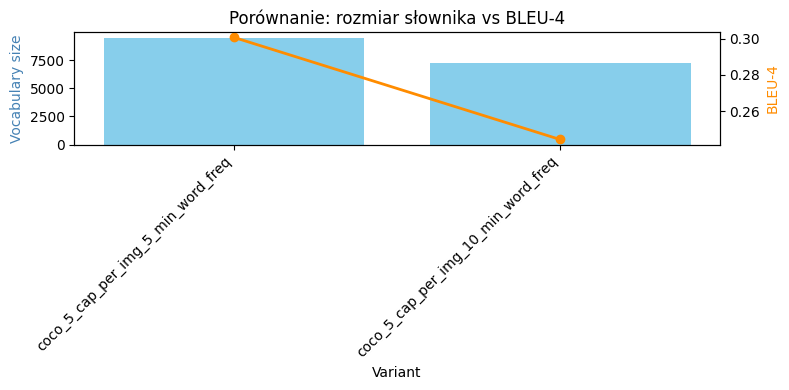

In [12]:
# Zapis wyników porównania i wykres
import os
import pandas as pd
import matplotlib.pyplot as plt

# Jeśli `results` to lista słowników, zapiszemy ją jako DataFrame i do CSV
try:
    df_results = pd.DataFrame(results)
except Exception:
    df_results = None

if df_results is not None:
    out_csv = os.path.join(os.getcwd(), 'results_vocab_size_comparison.csv')
    df_results.to_csv(out_csv, index=False)
    print(f"Saved results to: {out_csv}")
    display(df_results)

    # Wykres porównawczy: vocab_size (słupki) i BLEU-4 (linia)
    fig, ax1 = plt.subplots(figsize=(8, 4))
    x = range(len(df_results))
    ax1.bar(x, df_results['vocab_size'], color='skyblue', label='Vocab size')
    ax1.set_xlabel('Variant')
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_results['variant'], rotation=45, ha='right')
    ax1.set_ylabel('Vocabulary size', color='steelblue')

    ax2 = ax1.twinx()
    ax2.plot(x, df_results['bleu4'], color='darkorange', marker='o', linewidth=2, label='BLEU-4')
    ax2.set_ylabel('BLEU-4', color='darkorange')

    ax1.set_title('Porównanie: rozmiar słownika vs BLEU-4')
    fig.tight_layout()
    plt.show()
else:
    print('No results available to save or plot.')
